In [1]:
import numpy as np
import matplotlib.pyplot as plt
import drjit as dr
import mitsuba as mi
mi.set_variant('cuda_acoustic', 'llvm_acoustic', 'cuda_ad_acoustic', 'llvm_ad_acoustic')
from mitsuba import ScalarTransform4f as tf

# Forward Rendering: Shoebox room

In this notebook we will render the energy time curve of a shoebox scene. 

<div class="admonition important alert alert-block alert-success">

🚀 **You will learn how to:**
    
<ul>
  <li>Create a shoebox room scene entirely in Python</li>
  <li>Configure the Acoustic BSDF</li>
  <li>Do a visual rendering of the scene</li>
  <li>Do an acoustic rendering of the scene</li>
</ul>
    
</div>


## Room dimensions and material properties

In [2]:
room_dim       = np.array([6, 8, 4.0]) # length, width, height
emitter_pos    = np.array([3, 6, 1.2])
receiver_pos   = np.array([2, 1, 1.2])
emitter_radius = 0.5

The spectra for absorption and scattering coefficients can be defined in lists of frequency-value tuples.

The rendered frequencies can be chosen independently from the frequency nodes of the materials. 
The absorption and scattering spectra will be linearly interpolated to the rendered frequencies.

In [3]:
absorption_top     = [(100, 0.1), (500, 0.5), (20000, 0.1)]
scattering_top     = [(100, 0.3), (500, 0.5), (20000, 0.8)]

absorption_bottom  = [(100, 0.4), (500, 0.5), (20000, 0.5)]
scattering_bottom  = [(100, 0.3), (500, 0.6), (20000, 0.9)]

absorption_left    = [(100, 0.0), (500, 0.4), (20000, 0.6)]
scattering_left    = [(100, 0.2), (500, 0.3), (20000, 0.4)]

absorption_right   = [(100, 0.2), (500, 0.4), (20000, 0.5)]
scattering_right   = [(100, 0.3), (500, 0.5), (20000, 0.8)]

absorption_front   = [(100, 0.3), (500, 0.7), (20000, 0.2)]
scattering_front   = [(100, 0.1), (500, 0.2), (20000, 0.3)]

absorption_back    = [(100, 0.7), (500, 0.8), (20000, 0.9)]
scattering_back    = [(100, 0.2), (500, 0.4), (20000, 0.6)]

<div class="admonition important alert alert-block alert-warning">

⚠️ **Caution:**

All spectra evaluate to 0 outside of their frequency range.
This means that e.g. The spectrum <code>absorption = [(100, 0.7), (1000, 0.9)]</code> will evaluate to <code>absorption = 0</code> when evaluated at frequencies above 1000 Hz or below 100 Hz.

An absorption coefficient of 0 is, in most cases, not intended.
Make sure that the frequency range of your spectra includes all frequencies you want to render to prevent unexpected results.
Additional nodes can be used to extend the range: 
`absorption = [(20, 0.7), (100, 0.7), (1000, 0.9), (20000, 0.9)]`
</p>
</div>

## Set Up Scene

Now, we will build a shoebox scene from scratch using basic rectangle shapes.

We set up a spherical emitter with uniform radiance, define the BSDFs of the walls and then set up the scene geometry.

To build the scene geometry, we first build a cube with sidelengths of 1 m with one of the corners placed in the world origin, and then scale the cube to the desired room dimensions.

In [4]:
# Define a scene dictionary with a spherical emitter:
scene_dict = {
    'type': 'scene',

    'emitter': {
        'type': 'sphere',
        'radius': 0.1,
        'center': emitter_pos,
        'emitter': {
            'type': 'area',
            'radiance': {
                'type': 'uniform',
                'value': 50,
            }
        },
    },
}

# Add BSDFs for each surface:
surfaces = ['top', 'bottom', 'left', 'right', 'front', 'back']
absorption_values = [absorption_top,   absorption_bottom,
                     absorption_left,  absorption_right,
                     absorption_front, absorption_back]
scattering_values = [scattering_top,   scattering_bottom,
                     scattering_left,  scattering_right,
                     scattering_front, scattering_back]

for surface, scattering, absorption in zip(surfaces, scattering_values, absorption_values):
    scene_dict[f'bsdf_{surface}'] = {
        'type': 'acousticbsdf',
        'absorption': {
            'type': 'spectrum',
            'value': absorption,
        },
        'scattering': {
            'type': 'spectrum',
            'value': scattering,
        },
        'specular_lobe_width': 0.001,  # small value for ideal specular reflections
    }

# Define the 1 m x 1 m x 1 m cube geometry.
scene_dict['cube'] = {
    'type': 'shapegroup',
    'top': {
        'type': 'rectangle', # Rectangle in XY range [-1, 1] x [-1, 1]
        'bsdf': {'type': 'ref', 'id': 'bsdf_top'},
        'to_world': tf().translate([0, 0, 1]).scale(0.5).translate([1, 1, 0]), # transformations are applied from right to left. First we move the corner to the origin and then scale it to a 1m x 1m rectangle
        'flip_normals': True, # flip normals so the surface points inwards
        },
    'bottom': {
        'type': 'rectangle',
        'bsdf': {'type': 'ref', 'id': 'bsdf_bottom'},
        'to_world': tf().scale(0.5).translate([1, 1, 0.]),
        },
    'left': {
        'type': 'rectangle',
        'bsdf': {'type': 'ref', 'id': 'bsdf_left'},
        'to_world': tf().rotate(axis=[0, -1, 0], angle=90).scale(0.5).translate([1, 1, 0.]),
        'flip_normals': True,
    },
    'right': {
        'type': 'rectangle',
        'bsdf': {'type': 'ref', 'id': 'bsdf_right'},
        'to_world': tf().translate([1, 0, 1]).rotate(axis=[0., 1., 0.], angle=90).scale(0.5).translate([1, 1, 0.]),
        'flip_normals': True,
    },
    'front': {
        'type': 'rectangle',
        'bsdf': {'type': 'ref', 'id': 'bsdf_front'},
        'to_world': tf().rotate(axis=[1, 0, 0], angle=90).scale(0.5).translate([1, 1, 0.]),
        'flip_normals': True,
    },
    'back': {
        'type': 'rectangle',
        'bsdf': {'type': 'ref', 'id': 'bsdf_back'},
        'to_world': tf().translate([0, 1, 0]).rotate(axis=[1., 0., 0.], angle=90).scale(0.5).translate([1, 1, 0.]),
    },
}

# scale the shoebox to the room dimensions
scene_dict['shoebox'] = {
    'type': 'instance',
    'geometry': {'type': 'ref', 'id': 'cube'},
    'to_world': tf().scale(room_dim) # scale the 1m x 1m x 1m box to the room dimensions
}

# load the scene
scene = mi.load_dict(scene_dict)

## Visual Rendering

If we want to, we can visually render the scene using a standard camera and integrator from Mitsuba 3.
Note that we are using frequency spectra for our BSDFs, so Mitsuba's spectrum to RGB transformation does not produce expected results (Mitsuba expects spectra to be in wavelength space, not in frequency space).

Nonetheless, we can define a camera that uses a spectral film, which we can set up to render specific frequencies per channel.
Here, we set up the camera to be placed at the microphone position and point to the emitter.

In [5]:
camera = mi.load_dict({
    'type': 'perspective',
    'to_world': tf().look_at(
        origin=receiver_pos,  # camera position
        target=emitter_pos,  # point camera to the center of the room
        up=[0, 0, 1]
    ),
    'fov': 90,
    'film': {
        'type': 'specfilm',
        'width': 1920,
        'height': 1080,
        'band1': {
            'type': 'regular',
            'frequency_min': 100, # careful: materials are defined for f >= 100 Hz
            'frequency_max': 101,
            'values': '1, 1'
        },
        'band2': {
            'type': 'regular',
            'frequency_min': 500,
            'frequency_max': 501,
            'values': '1, 1'
        },
        'band3': {
            'type': 'regular',
            'frequency_min': 19999,
            'frequency_max': 20000, # careful: materials are defined for f <=20000 Hz
            'values': '1, 1'
        },
    }
})

integrator_visual = mi.load_dict({
    'type': 'path'
})

### Render visual scene

By passing the camera and the visual integrator to the `render` function, we can render our scene using those settings. The channels of the output image correspond to the frequency bands that we defined in the film.

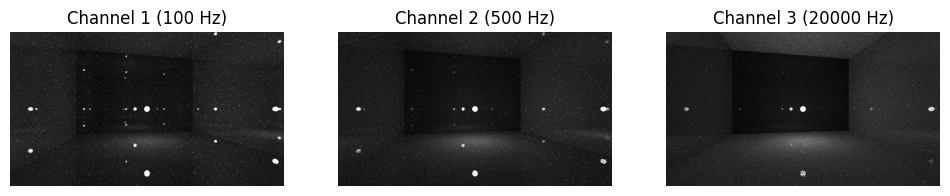

In [6]:
render_visual = True
if render_visual:
    image = mi.render(scene, sensor=camera, integrator=integrator_visual, spp=6)
    n_channels = image.shape[-1]

    fig, ax = plt.subplots(1, n_channels, figsize=(12, 5))
    for i in dr.arange(mi.Int, n_channels):
        ax[i].imshow(mi.util.convert_to_bitmap(image[..., i]))
        ax[i].axis('off')
        rendered_frequencies = [100, 500, 20000]
        ax[i].set_title(f'Channel {i+1} ({rendered_frequencies[i]} Hz)')

plt.show()

In these renderings, the room is shown from the receiver’s viewpoint, facing the emitter.

The reflection patterns reveal the expected behavior of the acoustic BSDF model: a pronounced specular component that appears as a bright spot, combined with diffuse scattering that gradually lights the surrounding surfaces. The absorption coefficient reduces both components, while the scattering coefficient controls the balance between specular and diffuse energy.

In this example, the scattering coefficient is low at low frequencies for all surfaces and higher at high frequencies. In the visual results, this produces many mirror-like reflections at 100 Hz, while the 20 kHz rendering appears more matte.

<div class="admonition important alert alert-block alert-info">

💡 **Follow Up:**

Change the parameter `specular_lobe_width` in the acoustic BSDF definition to see how the parameter affects the spatial distribution of the reflected energy.

</div>

## Acoustic Rendering

Rendering the acoustic scene is as easy as replacing the camera with a microphone and the integrator with an acoustic integrator:

In [7]:
max_time = 0.1 # maximum time to simulate in seconds
sampling_rate = 10000 # time bins per second
speed_of_sound = 343 # speed of sound in m/s
time_bins = int(max_time * sampling_rate)

microphone = mi.load_dict({
    'type': 'microphone',
    'origin': receiver_pos,
    'direction': emitter_pos,
    'film': {
        'type': 'tape',
        'frequencies': '100, 500, 20000',  # rendered frequencies
        'time_bins': time_bins,  # number of time bins
    },
})

integrator_acoustic = mi.load_dict({
    'type': 'acoustic_path',
    'speed_of_sound': speed_of_sound,
    'max_depth': -1,      # maximum path depth (-1 = no limit, 1 = direct sound only, 2 = up to 1 reflection, etc.)
    'max_time': max_time, # maximum propagation time in seconds
})



The microphone is an omnidirectional sensor with only one pixel per frequency bin. 
Therefore, the 'samples per pixel' `spp` defines the total number of rays per rendered frequency and we can use a rather high number.

In [8]:
spp = 2**20
etc = mi.render(scene, sensor=microphone, integrator=integrator_acoustic, spp=spp)

### Plot Energy Time Curve

Now we can plot the resulting Energy Time Curve (ETC):

In [9]:
def plot_etc(etc: mi.TensorXf, sampling_rate, max_time,
             dB = True, normalize = True, bottom=-70, *args, **kwargs):
    """Plot Energy Time Curve"""
    times = np.arange(max_time, step=1/sampling_rate)
    etc = etc.numpy().squeeze()

    plt.xlabel('Time in s')
    plt.ylabel('Amplitude')

    if normalize:
        etc  /= np.max(etc)

    if dB:
        with np.errstate(divide='ignore'):
            etc = 10 * np.nan_to_num(np.log10(np.abs(etc)), neginf=-300)
        plt.ylabel('Amplitude in dB')

    plt.plot(times, etc, *args, **kwargs)
    plt.xlim(0, max_time)
    plt.ylim(bottom=bottom, top=np.max(etc) + 5)

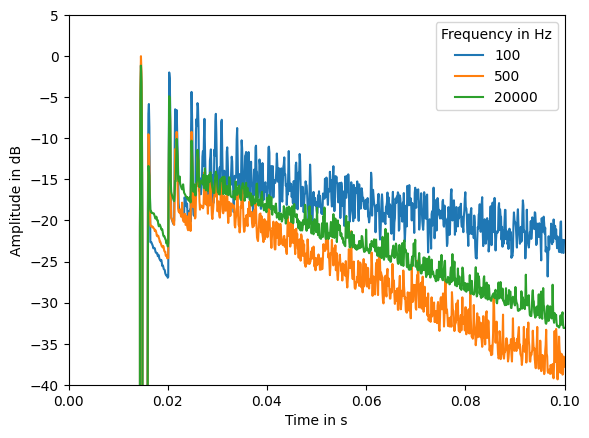

In [10]:
plot_etc(etc, sampling_rate, max_time, dB=True, normalize=True, bottom=-40)
plt.legend([100, 500, 20000], title='Frequency in Hz')  # add legend with frequency bins
plt.show()